In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
# Load the Excel file
xls = pd.ExcelFile(r'F:\ICT\EXIT TEST\dataset.xlsx')
df1 = pd.read_excel(xls, sheet_name='eurovision_meta')

df_bonus = pd.read_excel(xls, sheet_name='Voting Final')

In [10]:
df1.head()

,Unnamed: 0,Year,Country,Region,Artist,Song,Artist.gender,Group.Solo,Place,Points,...,danceability,tempo,speechiness,key,liveness,time_signature,mode,loudness,valence,Happiness
0,1,2009,Lithuania,Former Socialist Bloc,Sasha Son,Love,Male,Solo,23,23,...,0.598360,102.984,0.027817,9.0,0.078643,3.0,0.0,-9.082,0.482059,6.148232
1,2,2009,Israel,Independent,Noa and Mira Awad,There Must Be Another Way,Female,Group,16,53,...,0.604542,105.972,0.024996,8.0,0.084805,4.0,1.0,-6.059,0.426209,5.141887
2,3,2009,France,Western Europe,Patricia Kaas,Et s'il fallait le faire,Female,Solo,8,107,...,0.367344,124.005,0.043751,1.0,0.923905,4.0,1.0,-8.655,0.292870,5.069762
3,4,2009,Sweden,Scandinavia,Malena Ernman,La voix,Female,Solo,21,33,...,0.513202,128.021,0.034855,10.0,0.143708,4.0,1.0,-4.536,0.206493,5.502692
4,5,2009,Croatia,Former Yugoslavia,Igor Cukrov feat. Andrea,Lijepa Tena,Both,Group,18,45,...,0.590592,116.107,0.032406,1.0,0.079322,4.0,0.0,-4.427,0.344541,NaN


In [11]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 648 entries, 0 to 647
Data columns (total 30 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         648 non-null    int64  
 1   Year               648 non-null    int64  
 2   Country            648 non-null    object 
 3   Region             648 non-null    object 
 4   Artist             648 non-null    object 
 5   Song               648 non-null    object 
 6   Artist.gender      226 non-null    object 
 7   Group.Solo         226 non-null    object 
 8   Place              648 non-null    int64  
 9   Points             648 non-null    int64  
 10  Home.Away.Country  648 non-null    object 
 11  Home.Away.Region   648 non-null    object 
 12  Is.Final           648 non-null    int64  
 13  Semi.Final.Number  281 non-null    float64
 14  Song.In.English    648 non-null    int64  
 15  Song.Quality       648 non-null    float64
 16  Normalized.Points  648 non

In [ ]:
df1.describe()

In [13]:
#Duplicate Rows
print("Duplicate Rows:", df1.duplicated().sum())
# Remove duplicate rows
df1 = df1.drop_duplicates()


Duplicate Rows: 0


In [14]:
# Duplicate Columns
duplicate_columns = df1.columns[df1.T.duplicated()]
print("Duplicate Columns:")
print(duplicate_columns)
# Remove duplicate columns
df1 = df1.loc[:, ~df1.T.duplicated()]

Duplicate Columns:
Index([], dtype='object')


In [15]:
df1.shape

(648, 30)

In [16]:
df1= df1.drop(['Unnamed: 0'],axis = 1)

In [17]:
#CHECK MISSING VALUES
print("\nMissing Values :")
df1.isnull().sum()


Missing Values :


Year                   0
Country                0
Region                 0
Artist                 0
Song                   0
Artist.gender        422
Group.Solo           422
Place                  0
Points                 0
Home.Away.Country      0
Home.Away.Region       0
Is.Final               0
Semi.Final.Number    367
Song.In.English        0
Song.Quality           0
Normalized.Points      0
energy               166
duration             166
acousticness         168
danceability         166
tempo                166
speechiness          166
key                  166
liveness             166
time_signature       166
mode                 166
loudness             166
valence              168
Happiness            344
dtype: int64

In [18]:
# Missing numerical columns
missing_num_cols = [col for col in df1.select_dtypes(include=['number']).columns if df1[col].isnull().sum() > 0]

print("Missing Numerical Columns:\n", missing_num_cols)

Missing Numerical Columns:
 ['Semi.Final.Number', 'energy', 'duration', 'acousticness', 'danceability', 'tempo', 'speechiness', 'key', 'liveness', 'time_signature', 'mode', 'loudness', 'valence', 'Happiness']


In [23]:
missing_cols_nunique = df1[missing_num_cols].nunique()
print("\nUnique values in missing numerical columns:\n", missing_cols_nunique)


Unique values in missing numerical columns:
 Semi.Final.Number      2
energy               366
duration             349
acousticness         364
danceability         366
tempo                365
speechiness          366
key                   12
liveness             366
time_signature         5
mode                   2
loudness             356
valence              364
Happiness            220
dtype: int64


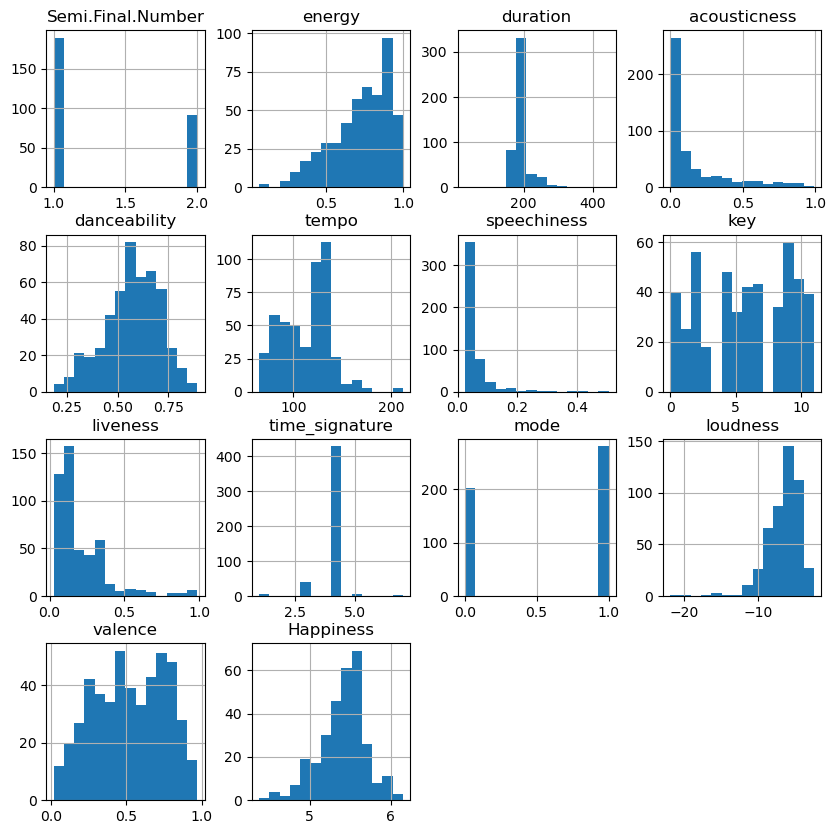

In [22]:
df1[missing_num_cols].hist(figsize=[10,10], bins=14)
plt.show()

#Missing Continuous numerical features which are skewed - are filled with Median
#Missing Discrte numerical features which are skewed -  are filled with Mode
#Categorical missing values filled using mode because mode represents the most frequent category

In [24]:
# 1.  Missing Continuous numerical features which are skewed - Median

for i in ['energy', 'duration', 'acousticness', 'danceability', 'tempo', 'speechiness','liveness','loudness', 'valence', 'Happiness']:
    df1[i] = df1[i].fillna(df1[i].median())

In [25]:
# 1.  Missing Discrte numerical features which are skewed - Mode

for i in ['Semi.Final.Number','key','time_signature', 'mode']:
    df1[i] = df1[i].fillna(df1[i].median())

In [26]:
#2. Missing categorical features
# Categorical missing values filled using mode because mode represents the most frequent category
missing_cat_cols = [col for col in df1.select_dtypes(include=['object']).columns 
                   if df1[col].isnull().sum() > 0]
print("\nMissing Categorical Columns:\n", missing_cat_cols)


Missing Categorical Columns:
 ['Artist.gender', 'Group.Solo']


In [32]:
for i in missing_cat_cols: 
    df1[i] = df1[i].fillna(df1[i].mode()[0])

In [33]:
df1.isna().sum()

Year                 0
Country              0
Region               0
Artist               0
Song                 0
Artist.gender        0
Group.Solo           0
Place                0
Points               0
Home.Away.Country    0
Home.Away.Region     0
Is.Final             0
Semi.Final.Number    0
Song.In.English      0
Song.Quality         0
Normalized.Points    0
energy               0
duration             0
acousticness         0
danceability         0
tempo                0
speechiness          0
key                  0
liveness             0
time_signature       0
mode                 0
loudness             0
valence              0
Happiness            0
dtype: int64

In [34]:
numerical_cols = df1.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = df1.select_dtypes(include=['object']).columns

print('Numerical Columns:\n', numerical_cols)
print('\nCategorical Columns:\n', categorical_cols)

Numerical Columns:
 Index(['Year', 'Place', 'Points', 'Is.Final', 'Semi.Final.Number',
       'Song.In.English', 'Song.Quality', 'Normalized.Points', 'energy',
       'duration', 'acousticness', 'danceability', 'tempo', 'speechiness',
       'key', 'liveness', 'time_signature', 'mode', 'loudness', 'valence',
       'Happiness'],
      dtype='object')

Categorical Columns:
 Index(['Country', 'Region', 'Artist', 'Song', 'Artist.gender', 'Group.Solo',
       'Home.Away.Country', 'Home.Away.Region'],
      dtype='object')


### TASK 2

In [43]:
print(df1["Artist.gender"].value_counts(dropna=False))

Artist.gender
Female    523
Male       94
Both       31
Name: count, dtype: int64


In [44]:
gender_points = df1.groupby("Artist.gender")["Points"].agg(["count", "mean", "median","std"])
print(gender_points)

               count        mean  median        std
Artist.gender                                      
Both              31   75.096774    64.0  52.446388
Female           523   71.001912    56.0  57.631193
Male              94  116.404255   105.5  81.109818


#Male artists have the highest average and median points
#male artists appear to have performed better in terms of point
#male scores also showed greater variability
#gender categories are highly imbalanced

In [46]:
print(df1["Group.Solo"].value_counts(dropna=False))

Group.Solo
Solo     575
Group     73
Name: count, dtype: int64


In [47]:
group_points = df1.groupby("Group.Solo")["Points"].agg(["count", "mean", "median","std"])
print(group_points)

            count       mean  median        std
Group.Solo                                     
Group          73  96.712329    84.0  69.506091
Solo          575  75.380870    59.0  62.123621


#groups scored considerably higher than solo artists in this dataset
#highly imbalanced between group and solo

C:\Users\USER\AppData\Local\Temp\ipykernel_5876\2497044642.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Artist.gender', y='Points', data=df1, palette='Set2')
C:\Users\USER\AppData\Local\Temp\ipykernel_5876\2497044642.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Group.Solo', y='Points', data=df1, palette='Set3')


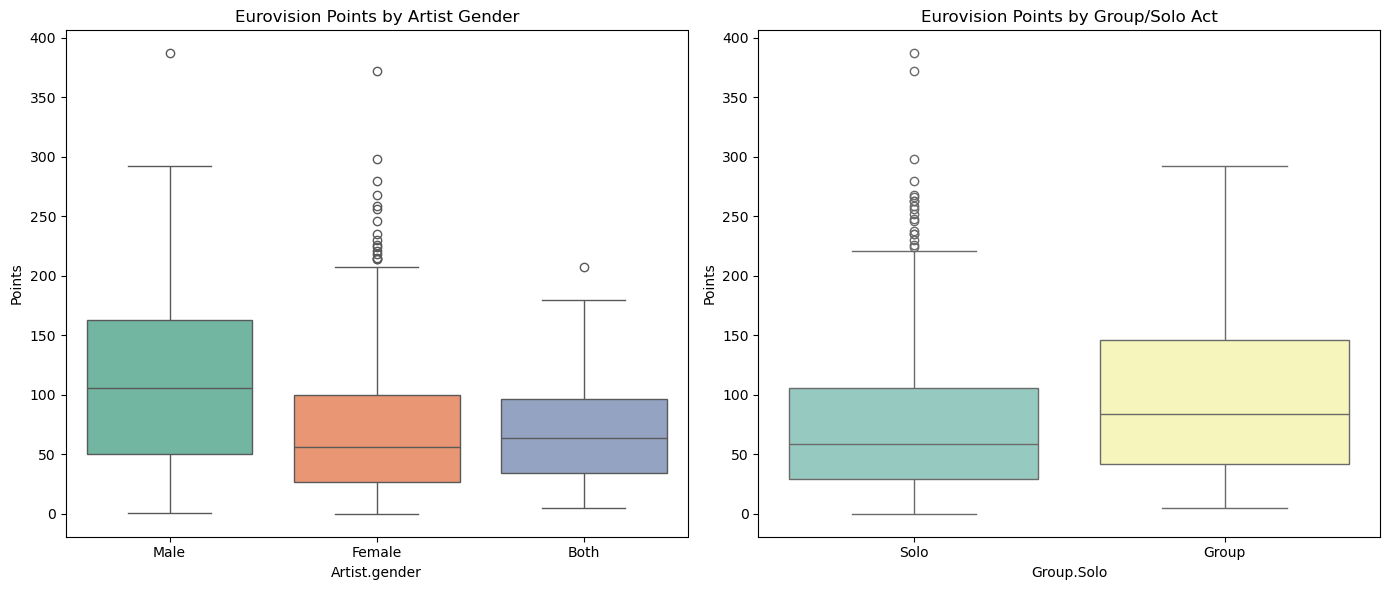

In [41]:
# Create a figure with two subplots side-by-side
plt.figure(figsize=(14, 6))

# Plot 1: Artist Gender vs Points
plt.subplot(1, 2, 1)
sns.boxplot(x='Artist.gender', y='Points', data=df1, palette='Set2')
plt.title('Eurovision Points by Artist Gender')

# Plot 2: Group/Solo vs Points
plt.subplot(1, 2, 2)
sns.boxplot(x='Group.Solo', y='Points', data=df1, palette='Set3')
plt.title('Eurovision Points by Group/Solo Act')

plt.tight_layout()
plt.show()

### TASK 3 

In [49]:
features = [
    "Year",
    "Artist.gender",
    "Group.Solo",
    "Song.In.English",
    "energy",
    "duration",
    "acousticness",
    "danceability",
    "tempo",
    "speechiness",
    "key",
    "liveness",
    "time_signature",
    "mode",
    "loudness",
    "valence",
    "Happiness"
]

x= df1[features]
y = df1["Points"]


### TASK 4

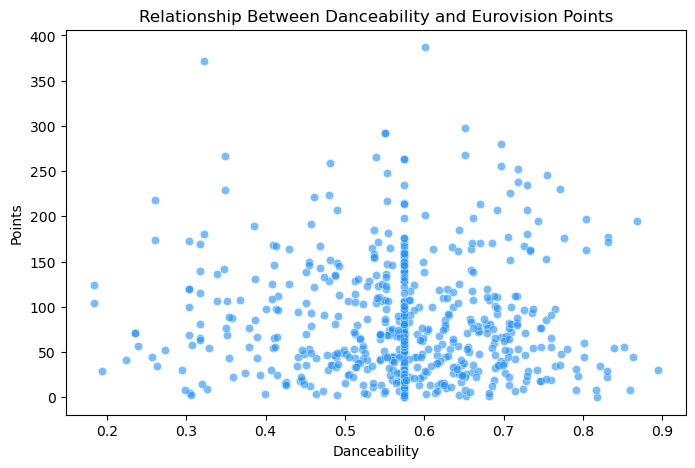

In [54]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(8, 5))
sns.scatterplot(x='danceability', y='Points', data=df1, alpha=0.6, color='dodgerblue')
plt.xlabel("Danceability")
plt.ylabel("Points")
plt.title('Relationship Between Danceability and Eurovision Points')

plt.show()

In [53]:
correlation = df1["danceability"].corr(df1["Points"])
print("Correlation:", correlation)

Correlation: -0.031369661583769706


The scatter plot shows no strong visible relationship between danceability and Eurovision points. 
The correlation is close to zero, indicating that danceability alone is not a strong predictor of points.

A song's danceability alone is unlikely to determine its Eurovision success. Other characteristics like
energy, song quality, artist characteristics and voting patterns may have a greater influence on the points received.
correlation coefficient of approximately -0.03, there is no meaningful linear relationship between a song's danceability and the points it receives

### TASK 5

In [55]:
x.head()

,Year,Artist.gender,Group.Solo,Song.In.English,energy,duration,acousticness,danceability,tempo,speechiness,key,liveness,time_signature,mode,loudness,valence,Happiness
0,2009,Male,Solo,1,0.678258,183.18476,0.563170,0.598360,102.984,0.027817,9.0,0.078643,3.0,0.0,-9.082,0.482059,6.148232
1,2009,Female,Group,1,0.794093,179.87873,0.068711,0.604542,105.972,0.024996,8.0,0.084805,4.0,1.0,-6.059,0.426209,5.141887
2,2009,Female,Solo,0,0.574628,227.97333,0.654078,0.367344,124.005,0.043751,1.0,0.923905,4.0,1.0,-8.655,0.292870,5.069762
3,2009,Female,Solo,1,0.672746,178.45660,0.119194,0.513202,128.021,0.034855,10.0,0.143708,4.0,1.0,-4.536,0.206493,5.502692
4,2009,Both,Group,0,0.733959,182.83057,0.323643,0.590592,116.107,0.032406,1.0,0.079322,4.0,0.0,-4.427,0.344541,5.464790


In [58]:
x_encoded = pd.get_dummies(x, columns=['Artist.gender', 'Group.Solo', 'Song.In.English'], dtype='int',drop_first=True)
x_encoded.head()

,Year,energy,duration,acousticness,danceability,tempo,speechiness,key,liveness,time_signature,mode,loudness,valence,Happiness,Artist.gender_Female,Artist.gender_Male,Group.Solo_Solo,Song.In.English_1
0,2009,0.678258,183.18476,0.563170,0.598360,102.984,0.027817,9.0,0.078643,3.0,0.0,-9.082,0.482059,6.148232,0,1,1,1
1,2009,0.794093,179.87873,0.068711,0.604542,105.972,0.024996,8.0,0.084805,4.0,1.0,-6.059,0.426209,5.141887,1,0,0,1
2,2009,0.574628,227.97333,0.654078,0.367344,124.005,0.043751,1.0,0.923905,4.0,1.0,-8.655,0.292870,5.069762,1,0,1,0
3,2009,0.672746,178.45660,0.119194,0.513202,128.021,0.034855,10.0,0.143708,4.0,1.0,-4.536,0.206493,5.502692,1,0,1,1
4,2009,0.733959,182.83057,0.323643,0.590592,116.107,0.032406,1.0,0.079322,4.0,0.0,-4.427,0.344541,5.464790,0,0,0,0


### TASK 6

In [61]:
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import GradientBoostingRegressor
import joblib

# Split the data
x_train, x_test, y_train, y_test = train_test_split(x_encoded, y, test_size = 0.2, random_state = 42)

In [62]:
def evaluate_model(model):
    # Train the model
    model.fit(x_train, y_train)
    # Prediction
    y_pred = model.predict(x_test)
    
    # Overall Metrics
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    print("Overall Performance")
    print("-------------------")
    print(f"MAE  : {mae:.2f}")
    print(f"MSE  : {mse:.2f}")
    print(f"R²   : {r2:.4f}")
    
    # Cross Validation
    scores = cross_val_score(model, x_train, y_train, cv=5, scoring='r2') 
    print("\nCross Validation")
    print("----------------")
    print("Fold R² Scores :", np.round(scores, 4))
    print("Average CV R²  :", round(scores.mean(), 4))

In [63]:
# Hyperparameter grid for Eurovision data
param_random_gb= {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [5, 8, 12, 15],                
    'learning_rate': [0.01, 0.03, 0.05, 0.1],   
    'subsample': [0.6, 0.75, 0.9, 1.0],          
    'max_features': ['sqrt', 'log2', 0.5, 0.8],  
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Initialize and run Randomized Search
regression_gb = GradientBoostingRegressor(random_state=42)
random_search_gb = RandomizedSearchCV(random_state=42, estimator=regression_gb, param_distributions=param_random_gb, n_iter=50, cv=5, scoring='neg_mean_absolute_error', verbose=1, n_jobs=-1)
random_search_gb.fit(x_train, y_train)

Fitting 5 folds for each of 50 candidates, totalling 250 fits


,estimator,GradientBoost...ndom_state=42)
,param_distributions,"{'learning_rate': [0.01, 0.03, ...], 'max_depth': [5, 8, ...], 'max_features': ['sqrt', 'log2', ...], 'min_samples_leaf': [1, 2, ...], ...}"
,n_iter,50
,scoring,'neg_mean_absolute_error'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [64]:
# Best parameters and evaluation
print("Best Parameters:", random_search_gb.best_params_)
print('\n--- Gradient Boosting Regressor')
best_gb = random_search_gb.best_estimator_
evaluate_model(best_gb)

Best Parameters: {'subsample': 0.6, 'n_estimators': 500, 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_features': 'log2', 'max_depth': 8, 'learning_rate': 0.01}

--- Gradient Boosting Regressor
Overall Performance
-------------------
MAE  : 43.82
MSE  : 3088.56
R²   : 0.2394

Cross Validation
----------------
Fold R² Scores : [0.2793 0.2827 0.0925 0.3607 0.0885]
Average CV R²  : 0.2207


#MAE of 43.84 demonstrate that the model successfully captures general structural trends in successful tracks, 
#but also highlights the inherent limits of predicting artistic 
#competitions purely through quantitative audio data.

In [65]:
joblib.dump(best_gb, 'eurovision_model.joblib')
joblib.dump(list(x_train.columns), 'model_columns.joblib')

['model_columns.joblib']